In [1]:
import datetime
import os
import glob
import gc
import pandas as pd
import xarray as xr
import numpy as np
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt 
from matplotlib import cm
from matplotlib import colors
import cmcrameri.cm as ccm

from params import boundaries
from myutil import make_ts, rescale_lists
plt.style.use('science.mplstyle')
projectdir = '/glade/campaign/uwyo/wyom0200/berkeley/'

In [2]:
years = range(1980, 2101)


/glade/u/home/mcowherd/wus-snow-drought/nbs/myutil.py:427: RuntimeWarning: invalid value encountered in double_scalars
  rescaled_values = [value / total for value, total in zip(values, totals)]
/glade/u/home/mcowherd/wus-snow-drought/nbs/myutil.py:427: RuntimeWarning: invalid value encountered in double_scalars
  rescaled_values = [value / total for value, total in zip(values, totals)]
/glade/derecho/scratch/mcowherd/tmp/ipykernel_22313/3448306084.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[i].set_xticklabels([1980,2000,2020,2040,2060,2080,2100])


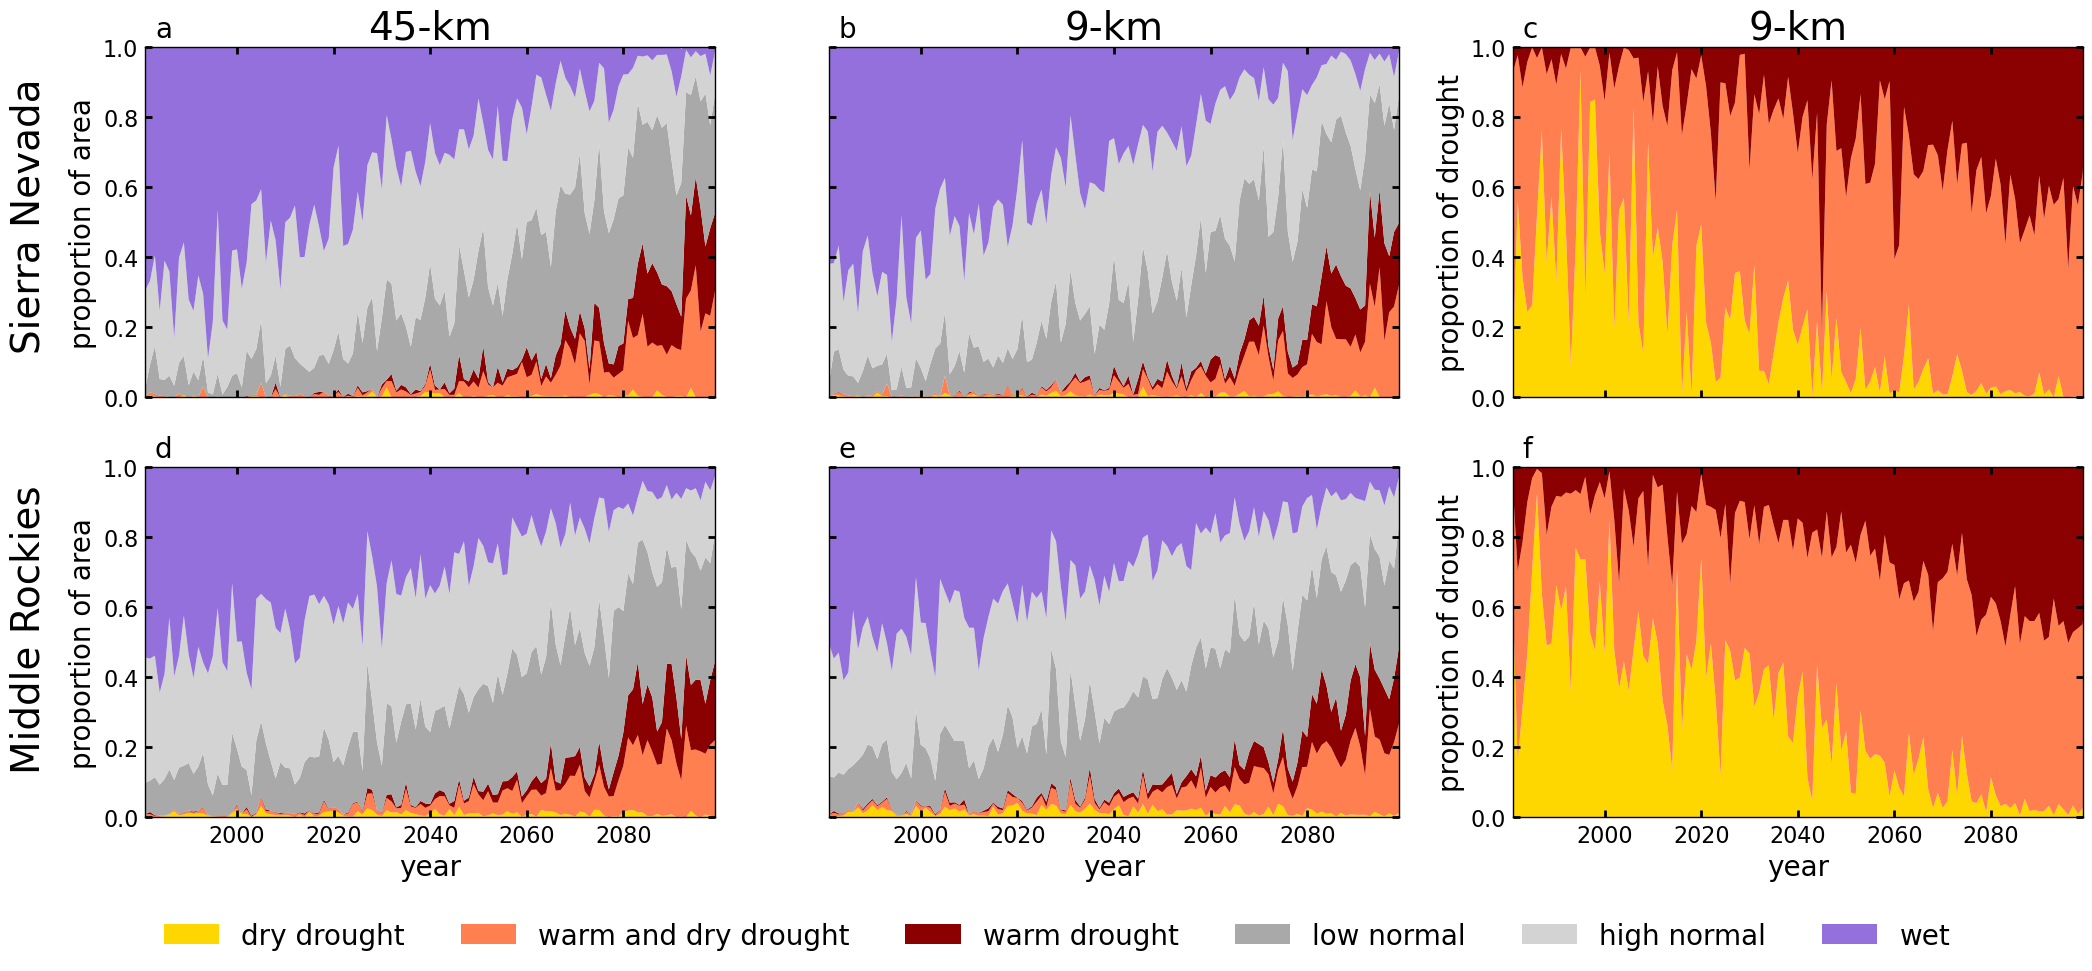

In [3]:
## third version: only the 45 and  9 km, transpose resolution and region, add a third column showing drought type (9km only)
setup = [['d01', 'CA'],['d02', 'CA'], ['d02', 'CA'], ['d01','WY'],['d02','WY'], ['d02','WY']]
color_list = ['gold', 'coral', 'darkred', 'darkgray', 'lightgray', 'mediumpurple']
label_list = ['dry drought', 'warm and dry drought', 'warm drought', 'low normal', 'high normal', 'wet']

fig, ax = plt.subplots(2,3, figsize = (25,10))
axs = ax.flatten()

savecat = []
for i, param in enumerate(setup):
    bounds = boundaries[param[0]][param[1]]
    categories = make_ts(param[0], bounds)
    if i in [2,5]:
        categories2 = {'dry': categories['dry'],
                  'warmdry':categories['warmdry'],
                  'warm': categories['warm']}
        categories = rescale_lists(categories2)
        labels = label_list[0:3]
        colors = color_list[0:3]
    else:
        labels = label_list
        colors = color_list
    if 'wet' in categories.keys():
         categories['wet'] = categories['wet'] + 0.02
    savecat.append(categories)
    axs[i].stackplot(years,categories.values(), labels = labels, colors = colors)
    axs[i].set_ylim((0,1))
    axs[i].set_xlim((1981,2099))
  
    if i in [1,4]:
        axs[i].set_yticklabels([])
    if i < 3:
        axs[i].set_xticklabels([])


axs[0].set_ylabel('proportion of area', fontsize = 20)
axs[3].set_ylabel('proportion of area', fontsize = 20)
axs[0].text(1953, 0.150, 'Sierra Nevada', fontsize = 28, rotation = 90)
axs[3].text(1953, 0.150, 'Middle Rockies', fontsize =28, rotation = 90)

axs[2].set_ylabel('proportion of drought', fontsize = 20)
axs[5].set_ylabel('proportion of drought', fontsize = 20)

axs[3].set_xlabel('year')
axs[4].set_xlabel('year')
axs[5].set_xlabel('year')
for i in range(3,6):
    axs[i].set_xticklabels([1980,2000,2020,2040,2060,2080,2100])


axs[4].legend(loc = 'lower center', bbox_to_anchor = (0.4,-0.45), ncol = 6, fontsize = 20)
axs[0].set_title('45-km', fontsize = 28)
axs[1].set_title('9-km', fontsize = 28)
axs[2].set_title('9-km', fontsize = 28)
#plt.tight_layout()

for i,label in enumerate([0,1,2,3,4,5]):
    axs[label].text(1983, 1.03, chr(i + 97))

plt.savefig('../figures/fig_stack.jpg', dpi = 400)
plt.show()